# Milestone 2: Advanced Data Analysis and Feature Engineering

This section extends Milestone 1 by adding statistical testing, advanced churn segmentation, feature engineering, feature selection, and model-ready transformations. These are the required components for Milestone 2: advanced analysis, engineered features, enhanced visualizations.

In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Mounting drive
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/DEPI R4/My_Final Project/WA_Fn-UseC_-Telco-Customer-Churn.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# Load dataset
m2_data = pd.read_csv(file_path)

## 1. Advanced Statistical Analysis

The goal of this section is to test whether churned and non-churned customers differ significantly across important numerical and categorical features.

In [34]:
from scipy.stats import ttest_ind
import pandas as pd

# Ensure 'TotalCharges' is numeric in m2_data
m2_data['TotalCharges'] = pd.to_numeric(
    m2_data['TotalCharges'], errors='coerce'
)
m2_data['TotalCharges'] = m2_data['TotalCharges'].fillna(
    m2_data['TotalCharges'].median()
)

# T-tests for numerical features
# H0: The mean value is the same for churned and non-churned customers.
# H1: The mean value is different between churned and non-churned customers.

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
t_test_results = []

for col in numerical_features:
    churn_yes = m2_data[m2_data["Churn"] == "Yes"][col]
    churn_no = m2_data[m2_data["Churn"] == "No"][col]
    stat, p_value = ttest_ind(churn_yes, churn_no, equal_var=False)

    t_test_results.append({
        "Feature": col,
        "Mean_Churned": churn_yes.mean(),
        "Mean_Not_Churned": churn_no.mean(),
        "T_Statistic": stat,
        "P_Value": p_value,
        "Significant_At_0.05": p_value < 0.05
    })

t_test_df = pd.DataFrame(t_test_results)
t_test_df

,Feature,Mean_Churned,Mean_Not_Churned,T_Statistic,P_Value,Significant_At_0.05
0,tenure,17.979133,37.569965,-34.823819,1.195495e-232,True
1,MonthlyCharges,74.441332,61.265124,18.407527,8.592449e-73,True
2,TotalCharges,1531.796094,2552.882494,-18.767951,2.059075e-75,True


### T-Test Interpretation

The t-test compares the average numerical values for churned vs non-churned customers. Features with p-values below 0.05 are statistically significant and should be considered important churn predictors.

In [36]:
from scipy.stats import chi2_contingency

# Chi-square tests for categorical features
# H0: The categorical feature and churn are independent.
# H1: The categorical feature and churn are associated.

categorical_features = [col for col in m2_data.columns if m2_data[col].dtype == "object" and col != "Churn"]
chi_square_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(m2_data[col], m2_data["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "Feature": col,
        "Chi2_Statistic": chi2,
        "P_Value": p_value,
        "Degrees_of_Freedom": dof,
        "Significant_At_0.05": p_value < 0.05
    })

chi_square_df = pd.DataFrame(chi_square_results).sort_values("P_Value")
chi_square_df

,Feature,Chi2_Statistic,P_Value,Degrees_of_Freedom,Significant_At_0.05
13,Contract,1184.596572,5.863038e-258,2,True
7,OnlineSecurity,849.998968,2.661150e-185,2,True
10,TechSupport,828.197068,1.443084e-180,2,True
6,InternetService,732.309590,9.571788e-160,2,True
15,PaymentMethod,648.142327,3.682355e-140,3,True
8,OnlineBackup,601.812790,2.079759e-131,2,True
9,DeviceProtection,558.419369,5.505219e-122,2,True
12,StreamingMovies,375.661479,2.667757e-82,2,True
11,StreamingTV,374.203943,5.528994e-82,2,True
14,PaperlessBilling,258.277649,4.073355e-58,1,True


### Chi-Square Interpretation

The chi-square test checks whether categorical variables are associated with churn. Very small p-values indicate strong evidence that the feature is related to churn behavior.

## 2. Feature Engineering

The following features are designed to capture customer loyalty, service engagement, and financial risk patterns.

In [37]:
# FEATURE ENGINEERING


import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

# Create a copy of the cleaned dataset
final_data = data.copy()

# Drop customerID because it is an identifier, not a predictive feature
if 'customerID' in final_data.columns:
    final_data = final_data.drop(columns=['customerID'])

# Convert TotalCharges to numeric
final_data['TotalCharges'] = pd.to_numeric(final_data['TotalCharges'], errors='coerce')

# Fill missing TotalCharges values
final_data['TotalCharges'] = final_data['TotalCharges'].fillna(
    final_data['TotalCharges'].median()
)

# Standardize service-related columns
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_columns:
    final_data[col] = final_data[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

# Create tenure group feature
final_data['tenure_group'] = pd.cut(
    final_data['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

# Create total services feature
final_data['TotalServices'] = final_data[service_columns].apply(
    lambda row: (row == 'Yes').sum(),
    axis=1
)

# Create average monthly spend feature
final_data['AvgMonthlySpend'] = final_data['TotalCharges'] / (final_data['tenure'] + 1)

# Create charge per service feature
final_data['ChargePerService'] = final_data['MonthlyCharges'] / (final_data['TotalServices'] + 1)

# Create long-term customer flag
final_data['IsLongTerm'] = np.where(final_data['tenure'] >= 24, 1, 0)

# Encode target variable
final_data['Churn'] = final_data['Churn'].map({
    'No': 0,
    'Yes': 1
})

print("Feature engineering completed.")
print("Dataset shape after feature engineering:", final_data.shape)

Feature engineering completed.
Dataset shape after feature engineering: (7043, 25)


In [39]:
# Feature engineering summary table
feature_engineering_summary = pd.DataFrame({
    "New Feature": ["tenure_group", "TotalServices", "AvgMonthlySpend", "ChargePerService", "IsLongTerm"],
    "Type": ["Categorical", "Numerical", "Numerical", "Numerical", "Binary"],
    "Business Meaning": [
        "Groups customers by lifecycle stage.",
        "Measures customer engagement through subscribed services.",
        "Approximates monthly value after adjusting for tenure.",
        "Identifies customers paying high charges relative to service usage.",
        "Flags loyal customers with at least two years of tenure."
    ],
    "Expected Model Impact": [
        "Helps model capture churn risk among new customers.",
        "Higher service engagement may reduce churn risk.",
        "Highlights high-value customers and pricing sensitivity.",
        "Can detect dissatisfaction caused by poor value-for-money.",
        "Simplifies loyalty behavior into a strong binary predictor."
    ]
})

feature_engineering_summary

,New Feature,Type,Business Meaning,Expected Model Impact
0,tenure_group,Categorical,Groups customers by lifecycle stage.,Helps model capture churn risk among new custo...
1,TotalServices,Numerical,Measures customer engagement through subscribe...,Higher service engagement may reduce churn risk.
2,AvgMonthlySpend,Numerical,Approximates monthly value after adjusting for...,Highlights high-value customers and pricing se...
3,ChargePerService,Numerical,Identifies customers paying high charges relat...,Can detect dissatisfaction caused by poor valu...
4,IsLongTerm,Binary,Flags loyal customers with at least two years ...,Simplifies loyalty behavior into a strong bina...


In [40]:
final_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,TotalServices,AvgMonthlySpend,ChargePerService,IsLongTerm
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,14.925000,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,2-4 Years,3,53.985714,14.237500,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,0-1 Year,3,36.050000,13.462500,0
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,3,40.016304,10.575000,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,0-1 Year,1,50.550000,35.350000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Mailed check,84.80,1990.50,0,1-2 Years,7,79.620000,10.600000,1
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Credit card (automatic),103.20,7362.90,0,4-6 Years,6,100.861644,14.742857,1
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,...,Yes,Electronic check,29.60,346.45,0,0-1 Year,1,28.870833,14.800000,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,Mailed check,74.40,306.60,1,0-1 Year,2,61.320000,24.800000,0


## 3. Enhanced Churn Visualizations

These charts focus on business interpretation, customer segmentation, and churn drivers.

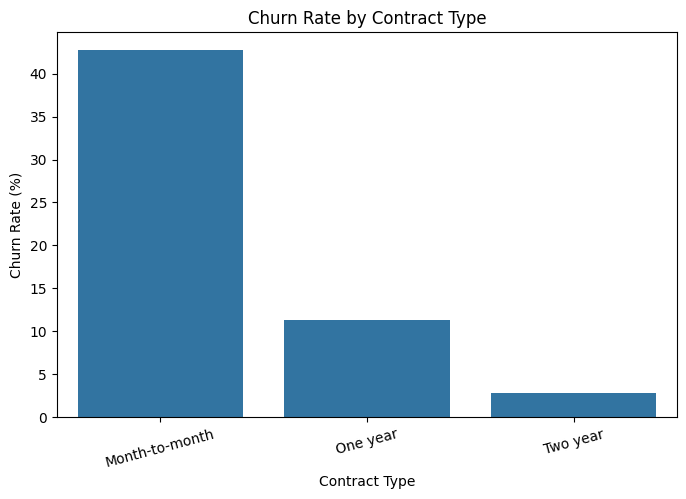

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [41]:
# Churn rate by contract type
contract_churn = pd.crosstab(m2_data["Contract"], m2_data["Churn"], normalize="index") * 100
contract_churn = contract_churn.sort_values("Yes", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn["Yes"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=15)
plt.show()

contract_churn

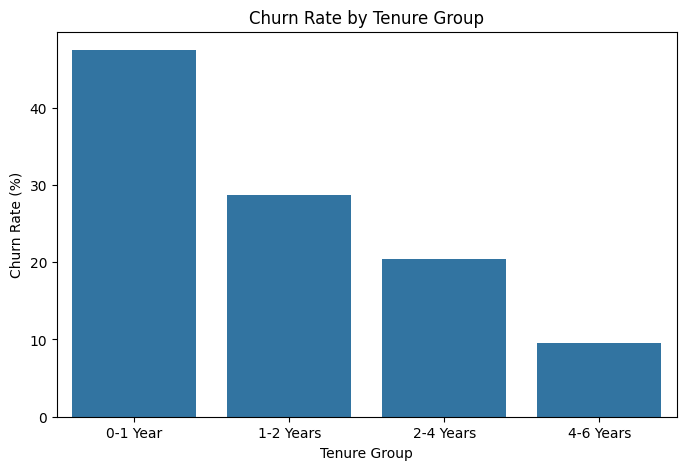

Churn,No,Yes
tenure_group,,
0-1 Year,52.561757,47.438243
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4-6 Years,90.486824,9.513176


In [43]:
# Create tenure group feature on m2_data for visualization
m2_data['tenure_group'] = pd.cut(
    m2_data['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

# Churn rate by tenure group
tenure_group_churn = pd.crosstab(m2_data["tenure_group"], m2_data["Churn"], normalize="index") * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_group_churn.index, y=tenure_group_churn["Yes"])
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.show()

tenure_group_churn

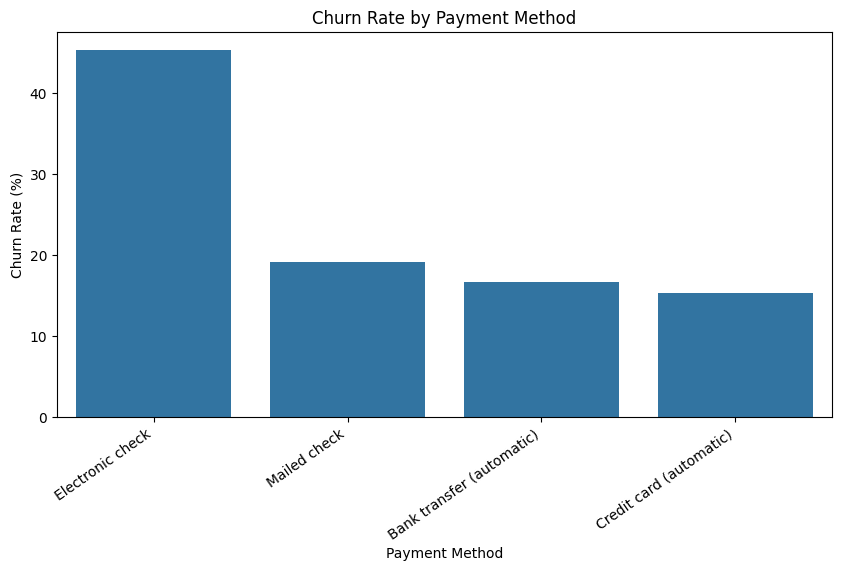

Churn,No,Yes
PaymentMethod,,
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101


In [44]:
# Churn rate by payment method
payment_churn = pd.crosstab(m2_data["PaymentMethod"], m2_data["Churn"], normalize="index") * 100
payment_churn = payment_churn.sort_values("Yes", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=payment_churn.index, y=payment_churn["Yes"])
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.xticks(rotation=35, ha="right")
plt.show()

payment_churn

## 4. Encoding, Scaling and Normalization

This section prepares the engineered dataset for feature selection and the next milestone.

In [45]:
# ENCODE CATEGORICAL DATA


# Identify categorical columns
categorical_columns = final_data.select_dtypes(include=['object', 'category']).columns

print("Categorical columns to encode:")
print(list(categorical_columns))

# One-hot encode categorical columns
final_encoded_data = pd.get_dummies(
    final_data,
    columns=categorical_columns,
    drop_first=True
)

# Convert boolean dummy columns from True/False to 1/0
bool_columns = final_encoded_data.select_dtypes(include=['bool']).columns
final_encoded_data[bool_columns] = final_encoded_data[bool_columns].astype(int)

print("Encoding completed.")
print("Dataset shape after encoding:", final_encoded_data.shape)

# Check that there are no boolean columns left
print("Boolean columns remaining:", final_encoded_data.select_dtypes(include=['bool']).columns.tolist())

Categorical columns to encode:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Encoding completed.
Dataset shape after encoding: (7043, 31)
Boolean columns remaining: []


In [46]:
final_encoded_data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,TotalServices,AvgMonthlySpend,ChargePerService,IsLongTerm,gender_Male,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2 Years,tenure_group_2-4 Years,tenure_group_4-6 Years
0,0,1,29.85,29.85,0,1,14.925000,14.925000,0,0,...,0,0,0,1,0,1,0,0,0,0
1,0,34,56.95,1889.50,0,3,53.985714,14.237500,1,1,...,0,1,0,0,0,0,1,0,1,0
2,0,2,53.85,108.15,1,3,36.050000,13.462500,0,1,...,0,0,0,1,0,0,1,0,0,0
3,0,45,42.30,1840.75,0,3,40.016304,10.575000,1,1,...,0,1,0,0,0,0,0,0,1,0
4,0,2,70.70,151.65,1,1,50.550000,35.350000,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,7,79.620000,10.600000,1,1,...,1,1,0,1,0,0,1,1,0,0
7039,0,72,103.20,7362.90,0,6,100.861644,14.742857,1,0,...,1,1,0,1,1,0,0,0,0,1
7040,0,11,29.60,346.45,0,1,28.870833,14.800000,0,0,...,0,0,0,1,0,1,0,0,0,0
7041,1,4,74.40,306.60,1,2,61.320000,24.800000,0,1,...,0,0,0,1,0,0,1,0,0,0


In [47]:
# NORMALIZE NUMERICAL FEATURES USING MINMAXSCALER

from sklearn.preprocessing import MinMaxScaler

# Numerical columns to scale
numerical_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'TotalServices',
    'AvgMonthlySpend',
    'ChargePerService'
]

# Keep only columns that exist
numerical_columns = [col for col in numerical_columns if col in final_encoded_data.columns]

scaler = MinMaxScaler()

final_encoded_data[numerical_columns] = scaler.fit_transform(
    final_encoded_data[numerical_columns]
)

print("Numerical normalization completed using MinMaxScaler.")
print("Scaled numerical columns:")
print(numerical_columns)

# Confirm minimum values are not negative
print("\nMinimum values after scaling:")
print(final_encoded_data[numerical_columns].min())

Numerical normalization completed using MinMaxScaler.
Scaled numerical columns:
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgMonthlySpend', 'ChargePerService']

Minimum values after scaling:
tenure              0.0
MonthlyCharges      0.0
TotalCharges        0.0
TotalServices       0.0
AvgMonthlySpend     0.0
ChargePerService    0.0
dtype: float64


In [48]:
final_encoded_data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,TotalServices,AvgMonthlySpend,ChargePerService,IsLongTerm,gender_Male,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2 Years,tenure_group_2-4 Years,tenure_group_4-6 Years
0,0,0.013889,0.115423,0.001275,0,0.125,0.004136,0.255487,0,0,...,0,0,0,1,0,1,0,0,0,0
1,0,0.472222,0.385075,0.215867,0,0.375,0.032272,0.231343,1,1,...,0,1,0,0,0,0,1,0,1,0
2,0,0.027778,0.354229,0.010310,1,0.375,0.019352,0.204126,0,1,...,0,0,0,1,0,0,1,0,0,0
3,0,0.625000,0.239303,0.210241,0,0.375,0.022209,0.102722,1,1,...,0,1,0,0,0,0,0,0,1,0
4,0,0.027778,0.521891,0.015330,1,0.125,0.029797,0.972783,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0.333333,0.662189,0.227521,0,0.875,0.050736,0.103600,1,1,...,1,1,0,1,0,0,1,1,0,0
7039,0,1.000000,0.845274,0.847461,0,0.750,0.066037,0.249091,1,0,...,1,1,0,1,1,0,0,0,0,1
7040,0,0.152778,0.112935,0.037809,0,0.125,0.014181,0.251097,0,0,...,0,0,0,1,0,1,0,0,0,0
7041,1,0.055556,0.558706,0.033210,1,0.250,0.037555,0.602283,0,1,...,0,0,0,1,0,0,1,0,0,0


## 5. Feature Selection

Feature selection identifies which variables are most useful for churn prediction. This section uses Random Forest feature importance.

In [49]:
# FEATURE SELECTION
# Select ONLY Top 15 Most Significant Features

from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = final_encoded_data.drop(columns=['Churn'])
y = final_encoded_data['Churn']

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X, y)

# Feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display Top 15 features
top_15_features = feature_importance.head(15)

print("Top 15 Most Significant Features:")
display(top_15_features)

# Extract only feature names
selected_features = top_15_features['Feature'].tolist()

print("\nSelected Features:")
print(selected_features)

# Create final selected dataset
final_selected_data = final_encoded_data[
    selected_features + ['Churn']
]

print("\nFinal selected dataset shape:")
print(final_selected_data.shape)

Top 15 Most Significant Features:


,Feature,Importance
6,ChargePerService,0.151390
3,TotalCharges,0.114329
1,tenure,0.111737
2,MonthlyCharges,0.103838
5,AvgMonthlySpend,0.103051
22,Contract_Two year,0.048179
13,InternetService_Fiber optic,0.034084
25,PaymentMethod_Electronic check,0.027957
21,Contract_One year,0.023447
7,IsLongTerm,0.022775



Selected Features:
['ChargePerService', 'TotalCharges', 'tenure', 'MonthlyCharges', 'AvgMonthlySpend', 'Contract_Two year', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_One year', 'IsLongTerm', 'TotalServices', 'PaperlessBilling_Yes', 'gender_Male', 'tenure_group_4-6 Years', 'Partner_Yes']

Final selected dataset shape:
(7043, 16)


In [50]:
# EXPORT THE FINAL CLEANED DATA

# Export full encoded dataset
final_encoded_data.to_csv(
    'final_cleaned_encoded_normalized_customer_churn.csv',
    index=False
)

# Export Top 15 selected features dataset
final_selected_data.to_csv(
    'final_top15_selected_features_customer_churn.csv',
    index=False
)

# Export feature importance ranking
feature_importance.to_csv(
    'feature_importance_ranking.csv',
    index=False
)

print("Files exported successfully.")

Files exported successfully.


In [52]:
from google.colab import files

files.download('final_cleaned_encoded_normalized_customer_churn.csv')
files.download('final_top15_selected_features_customer_churn.csv')
files.download('feature_importance_ranking.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>